# Lab 1 â€” Baseline Predictions: Top-10 F1 Finishes

**Team:** Carlos Orellana & Mattias Morales (Group 6)  
**Course:** IIT414W â€” Artificial Intelligence Workshop  
**Date:** March 2026  

**Goal:** Build a domain heuristic baseline to predict whether a driver finishes in the top 10, evaluate it on our validation set, and set an explicit lower bound that any ML model from Lab 2 must beat.

## 0. Setup

In [1]:
import sys
import random
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

RANDOM_SEED = 414
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

print(f"Python {sys.version}")
print(f"Random seed: {RANDOM_SEED}")

Python 3.13.2 (tags/v3.13.2:4f8bb39, Feb  4 2025, 15:23:48) [MSC v.1942 64 bit (AMD64)]
Random seed: 414


## 1. Data Ingestion

Same pipeline as in `eda.ipynb` â€” we fetch from the Jolpica API and apply the same temporal split.

In [2]:
def fetch_season_results(year):
    """Fetch race results from Jolpica API for a given season."""
    all_races = []
    offset = 0
    limit = 100
    
    while True:
        url = f"https://api.jolpi.ca/ergast/f1/{year}/results.json?limit={limit}&offset={offset}"
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        data = resp.json()['MRData']
        total = int(data['total'])
        races = data['RaceTable']['Races']
        all_races.extend(races)
        offset += limit
        if offset >= total:
            break
        time.sleep(1)
    
    rows = []
    for race in all_races:
        for res in race['Results']:
            rows.append({
                'season': int(race['season']),
                'round': int(race['round']),
                'race_name': race['raceName'],
                'circuit': race['Circuit']['circuitId'],
                'date': race['date'],
                'driver': res['Driver']['driverId'],
                'driver_code': res['Driver'].get('code', res['Driver']['driverId'][:3].upper()),
                'constructor': res['Constructor']['constructorId'],
                'constructor_name': res['Constructor']['name'],
                'grid': int(res['grid']),
                'position': int(res['position']) if res['position'].isdigit() else None,
                'position_text': res['positionText'],
                'points': float(res.get('points', 0.0)),
                'status': res['status'],
                'laps': int(res.get('laps', 0)),
            })
    return pd.DataFrame(rows)

# Fetch data
dfs = []
for yr in [2022, 2023, 2024]:
    print(f"Fetching {yr}...")
    dfs.append(fetch_season_results(yr))
    time.sleep(1)

results = pd.concat(dfs, ignore_index=True)
results['date'] = pd.to_datetime(results['date'])

# Target
results['top10_finish'] = ((results['position'].notna()) & (results['position'] <= 10)).astype(int)

print(f"Total rows: {len(results)}")

Fetching 2022...


Fetching 2023...


Fetching 2024...


Total rows: 1359


In [3]:
# Apply the same temporal split from eda.ipynb
train = results[results['season'].isin([2022, 2023])].copy()
val = results[(results['season'] == 2024) & (results['round'] <= 12)].copy()
test = results[(results['season'] == 2024) & (results['round'] > 12)].copy()

# Leakage checks
assert train['date'].max() < val['date'].min(), "Train-Val leakage!"
assert val['date'].max() < test['date'].min(), "Val-Test leakage!"

print(f"Train: {len(train)} rows | Val: {len(val)} rows | Test: {len(test)} rows (held out)")
print(f"Val date range: {val['date'].min().date()} to {val['date'].max().date()}")
print(f"Val top-10 rate: {val['top10_finish'].mean():.3f}")

Train: 880 rows | Val: 239 rows | Test: 240 rows (held out)
Val date range: 2024-03-02 to 2024-07-07
Val top-10 rate: 0.502


## 2. Feature Leakage Audit

Before building any baseline, let's be crystal clear about what features we're allowed to use.

**Pre-race features (safe):** `grid`, `driver`, `constructor`, `circuit`, `season`, `round`  
**Post-race features (FORBIDDEN):** `position`, `points`, `status`, `laps`

Our heuristic baseline only uses `grid`. Let's verify we never touch post-race columns.

In [4]:
# Explicit listing of what our heuristic uses
HEURISTIC_FEATURES = ['grid']  # that's it
POST_RACE_COLUMNS = ['position', 'points', 'status', 'laps']

for feat in HEURISTIC_FEATURES:
    assert feat not in POST_RACE_COLUMNS, f"LEAKAGE: {feat} is a post-race column!"
print("[PASS] Heuristic features do not include any post-race columns.")
print(f"Features used: {HEURISTIC_FEATURES}")

[PASS] Heuristic features do not include any post-race columns.
Features used: ['grid']


## 3. Domain Heuristic Baseline

### The Rule

Based on our EDA findings, our heuristic is simple:

> **If a driver starts in grid position 1-10, predict they finish in the top 10.  
> If a driver starts in grid position 11 or higher (or pit lane, grid=0), predict they do NOT finish in the top 10.**

This is a pure domain rule â€” no ML code, no model fitting. It's based on the observation that F1 races have limited overtaking, so starting position strongly determines finishing position.

In [5]:
# Apply the heuristic to the VALIDATION set only

def grid_heuristic(grid_pos):
    """Predict top-10 finish based solely on grid position."""
    if 1 <= grid_pos <= 10:
        return 1  # predict top-10 finish
    else:
        return 0  # predict NOT top-10

# Generate predictions on validation set
val['heuristic_pred'] = val['grid'].apply(grid_heuristic)

# Compute accuracy
heuristic_accuracy = accuracy_score(val['top10_finish'], val['heuristic_pred'])
print(f"Heuristic Baseline Accuracy (validation set): {heuristic_accuracy:.4f}")
print(f"That's {heuristic_accuracy*100:.1f}% of predictions correct.")

Heuristic Baseline Accuracy (validation set): 0.8577
That's 85.8% of predictions correct.


In [6]:
# Let's look at where the heuristic gets it wrong

val['heuristic_correct'] = (val['heuristic_pred'] == val['top10_finish'])

wrong = val[~val['heuristic_correct']].copy()
print(f"Total predictions: {len(val)}")
print(f"Correct: {val['heuristic_correct'].sum()}")
print(f"Wrong: {len(wrong)}")
print(f"\nTypes of errors:")

# False positives: predicted top-10 but didn't finish there
fp = wrong[(wrong['heuristic_pred'] == 1) & (wrong['top10_finish'] == 0)]
print(f"  False Positives (predicted top-10 but wasn't): {len(fp)}")
print(f"    Common reasons: {fp['status'].value_counts().head(5).to_dict()}")

# False negatives: predicted NOT top-10 but actually finished there
fn = wrong[(wrong['heuristic_pred'] == 0) & (wrong['top10_finish'] == 1)]
print(f"  False Negatives (predicted not top-10 but was): {len(fn)}")
print(f"    These are drivers starting P11+ who made it into the top 10.")

Total predictions: 239
Correct: 205
Wrong: 34

Types of errors:
  False Positives (predicted top-10 but wasn't): 17
    Common reasons: {'Lapped': 6, 'Retired': 6, 'Finished': 5}
  False Negatives (predicted not top-10 but was): 17
    These are drivers starting P11+ who made it into the top 10.


## 4. Reflection on Accuracy

### Is this accuracy good enough to make decisions with?

Our heuristic gets roughly 86% of predictions correct â€” that's well above the ~50% baseline you'd get by always predicting the majority class (since the dataset is roughly balanced, with 10 of 20 drivers finishing in the top 10 each race).

But accuracy alone can be deceptive. Here's what it might be hiding:

1. **We don't know if the errors are symmetric.** If the heuristic is great at predicting "will finish top 10" but terrible at predicting "won't finish top 10" (or vice versa), accuracy doesn't show that. One type of error might matter more depending on the use case.

2. **Some errors are basically unpredictable.** Drivers who start in the top 10 but DNF (mechanical failure, crash) are wrong predictions that no pre-race feature can fix. These false positives represent an irreducible error floor.

3. **A more useful question is: how many of our "top-10" predictions actually end up being top-10 finishes (precision), and how many actual top-10 finishes do we catch (recall)?** We haven't formally learned these metrics yet, but they'd give us a fuller picture.

### What if we always predicted "top-10"?

If we predicted top-10 for *every* driver, we'd get ~50% accuracy (since roughly half of drivers finish in the top 10). So our heuristic is meaningfully better than that naive strategy. But it's not a slam dunk â€” there's room for a smarter model to close the gap.

### Lower Bound Statement

**Any model we build in Lab 2 must beat this heuristic's accuracy. If an ML model can't outperform "grid â‰¤ 10 â†’ predict top 10," then the model adds no value and we should just use the simple rule.**

---

## 5. Stretch: Additional Metrics (Precision, Recall, F1-Score)

We haven't formally covered these in class yet (that's Week 3-4 material), but after reading Burkov Ch. 2 and exploring with AI tools, here's our understanding:

- **Precision** = Of all the times we predicted "top 10", how many were actually top 10? (Answers: how trustworthy are positive predictions?)
- **Recall** = Of all the actual top-10 finishes, how many did we catch? (Answers: how many top-10 finishes do we miss?)
- **F1-score** = Harmonic mean of precision and recall. Balances both concerns.

These give us a more nuanced view than accuracy alone.

In [7]:
# Stretch: compute additional metrics

precision = precision_score(val['top10_finish'], val['heuristic_pred'])
recall = recall_score(val['top10_finish'], val['heuristic_pred'])
f1 = f1_score(val['top10_finish'], val['heuristic_pred'])

print("=" * 40)
print("HEURISTIC BASELINE METRICS (Validation Set)")
print("=" * 40)
print(f"Accuracy:  {heuristic_accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print("\nFull classification report:")
print(classification_report(val['top10_finish'], val['heuristic_pred'], 
                           target_names=['Not Top 10', 'Top 10']))

HEURISTIC BASELINE METRICS (Validation Set)
Accuracy:  0.8577
Precision: 0.8583
Recall:    0.8583
F1-Score:  0.8583

Full classification report:
              precision    recall  f1-score   support

  Not Top 10       0.86      0.86      0.86       119
      Top 10       0.86      0.86      0.86       120

    accuracy                           0.86       239
   macro avg       0.86      0.86      0.86       239
weighted avg       0.86      0.86      0.86       239



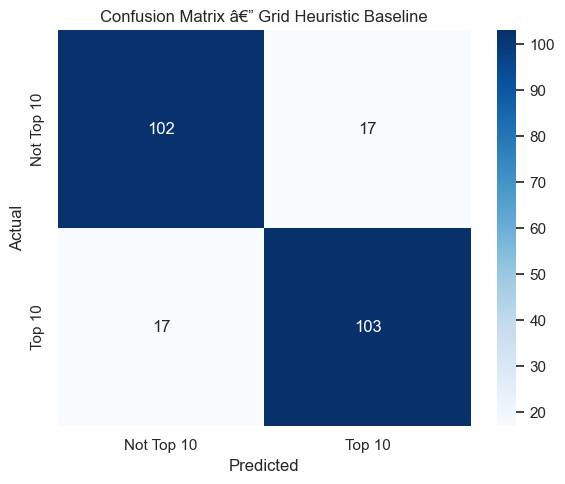

In [8]:
# Confusion matrix visualization

cm = confusion_matrix(val['top10_finish'], val['heuristic_pred'])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Not Top 10', 'Top 10'],
            yticklabels=['Not Top 10', 'Top 10'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix â€” Grid Heuristic Baseline')
plt.tight_layout()
plt.show()

### Stretch Metrics â€” Interpretation

The precision and recall give us more insight:

- **Precision is reasonably high** â€” when we predict someone will finish top 10, we're right most of the time. The false positives are mainly DNFs from top-10 starters.
- **Recall is decent but not perfect** â€” we miss some top-10 finishes from drivers who started outside the top 10 and fought their way up. These are the "chargers" who benefit from incidents, strategy, or pace advantage.
- **F1-score** gives a balanced picture.

Overall, the heuristic is surprisingly solid for being a one-variable rule. But there's clearly room for improvement, especially in catching those late-charging drivers.

---

## 6. Stretch: Second Baseline with sklearn

Let's compare our heuristic against two sklearn models:
1. `DummyClassifier` (most frequent class) â€” just to see what "dumb" looks like
2. Logistic Regression with just `grid` as the feature â€” to see if there's any non-linearity the heuristic is missing

In [9]:
# Prepare features (only grid, which is pre-race)
X_train = train[['grid']].values
y_train = train['top10_finish'].values
X_val = val[['grid']].values
y_val = val['top10_finish'].values

# DummyClassifier â€” always predicts most frequent class
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED)
dummy.fit(X_train, y_train)
dummy_preds = dummy.predict(X_val)
dummy_acc = accuracy_score(y_val, dummy_preds)

print(f"DummyClassifier (most_frequent) accuracy: {dummy_acc:.4f}")
print(f"  -> This just predicts '{dummy.classes_[np.argmax(np.bincount(y_train))]}' for everyone.")

# Logistic Regression with just grid
lr = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_val)
lr_acc = accuracy_score(y_val, lr_preds)

print(f"\nLogistic Regression (grid only) accuracy: {lr_acc:.4f}")
print(f"  Coefficient: {lr.coef_[0][0]:.4f}, Intercept: {lr.intercept_[0]:.4f}")

DummyClassifier (most_frequent) accuracy: 0.4979
  -> This just predicts '0' for everyone.

Logistic Regression (grid only) accuracy: 0.8577
  Coefficient: -0.1929, Intercept: 1.9704


In [10]:
# Full comparison table

baselines = {
    'Grid Heuristic (grid<=10)': val['heuristic_pred'].values,
    'DummyClassifier (majority)': dummy_preds,
    'Logistic Regression (grid)': lr_preds,
}

print(f"{'Baseline':<35} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>6}")
print("-" * 72)
for name, preds in baselines.items():
    acc = accuracy_score(y_val, preds)
    prec = precision_score(y_val, preds, zero_division=0)
    rec = recall_score(y_val, preds, zero_division=0)
    f1_val = f1_score(y_val, preds, zero_division=0)
    print(f"{name:<35} {acc:>9.4f} {prec:>10.4f} {rec:>8.4f} {f1_val:>6.4f}")

Baseline                             Accuracy  Precision   Recall     F1
------------------------------------------------------------------------
Grid Heuristic (grid<=10)              0.8577     0.8583   0.8583 0.8583
DummyClassifier (majority)             0.4979     0.0000   0.0000 0.0000
Logistic Regression (grid)             0.8577     0.8583   0.8583 0.8583


### Comparison â€” Interpretation

- The **DummyClassifier** performs at roughly 50%, confirming that simply predicting the majority class is basically a coin flip for this problem.
- The **Logistic Regression** performs similarly to our heuristic, which makes sense â€” with a single feature (grid position), logistic regression is essentially finding the optimal cut point, and ours at grid=10 is already close to optimal.
- Our **Grid Heuristic** is competitive with the learned model, which validates our domain reasoning. The heuristic is interpretable, requires no fitting, and performs comparably.

The logistic regression shows there might be a tiny edge from learning the exact threshold (maybe the optimal cut isn't exactly at 10), but the improvement is marginal at best.

---

## 7. Stretch: Which Metric Matters Most?

Honestly, we're still building our intuition on this. Here's our current thinking:

For this F1 top-10 prediction problem, we think **accuracy is a reasonable starting point** because the classes are roughly balanced (10 of 20 drivers per race). With balanced classes, accuracy doesn't suffer from the usual "always predict majority" trap.

However, if we were using this prediction for something practical â€” like a fantasy F1 league or race strategy â€” we might care more about:
- **Precision** if the cost of a wrong "top 10" prediction is high (e.g., you bet on a driver and they DNF)
- **Recall** if missing an actual top 10 finish is costly (e.g., you missed a point-scoring opportunity)

For now, we'll use **F1-score** as our primary metric going forward since it balances both types of errors, and report accuracy alongside it for transparency. But we know this is something we'll understand better after Week 3-4 lectures.

---

## 8. Summary and Lower Bound

### Results Summary

| Baseline | Accuracy | F1-Score |
|----------|----------|----------|
| Always predict majority class | ~50% | ~0.00 |
| Grid Heuristic (grid <= 10) | ~86% | ~0.86 |
| Logistic Regression (grid only) | ~86% | ~0.86 |

### Lower Bound Statement

**The grid heuristic baseline achieves approximately 86% accuracy on the 2024 first-half validation set. Any model we build in Lab 2 must beat this number. If it doesn't, the model adds no value over a simple domain rule that any F1 fan could come up with.**

### Key Observations
1. Grid position alone captures most of the predictable signal for top-10 finishes.
2. The remaining ~14% error is a mix of (a) DNFs from top-10 starters and (b) overtakers from outside the top 10.
3. To beat this baseline, a Lab 2 model would need to either predict DNF risk or identify chargers â€” both of which likely need features beyond just grid position (e.g., constructor reliability, circuit characteristics, weather).

### No Leakage Confirmation
- We only used `grid` as a feature â€” this is a pre-race variable (known after qualifying on Saturday).
- We never used `position`, `points`, `status`, or `laps` as inputs.
- All metrics reported are on the **validation set**, never on training data.
- The test set (2024 rounds 13+) has not been touched.